# Stage 02 — Baseline CPU Solver for ADAN-86 Pressure Propagation (BG wall model)

This notebook runs the baseline pure-CPU 1D ADAN-86 pressure propagation solver.

This version is adapted for the fixed Stage 01 parser output:

```python
adan_parsed_bg.pkl
```

The important change is that wall thickness and wave speed now come from `BG_Modules_v2.cellml`, not from the old fallback `h/r = 0.10`.


## Load parsed ADAN network with BG wall model

This notebook starts from the parsed ADAN-86 network created in the fixed Stage 01 notebook.

Expected input file:

```python
adan_parsed_bg.pkl
```

This file contains the same solver-facing arrays as the old parser, plus BG wall-model diagnostics:

- vessel names and traversal order
- topology tables
- root vessel index
- terminal vessel indices
- vessel geometry
- BG wall thickness `hv`
- pressure-area stiffness `betav`
- wave speeds `c0v`
- characteristic impedances `Z0v`
- numerical grid sizes
- parser diagnostics and wall-model metadata

Important: do not mix this notebook with the old `adan_parsed.pkl`, because the old file used the fallback `h/r = 0.10`.


In [1]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import trapezoid

# Load fixed parsed ADAN data
PARSED_FILE = Path("adan_parsed_bg.pkl")

with open(PARSED_FILE, "rb") as f:
    adan = pickle.load(f)

globals().update(adan)

# Basic compatibility checks
required_keys = [
    "order", "topology_df", "vessel_to_idx",
    "A0v", "betav", "c0v", "Z0v", "dxv", "Nv",
    "parent_idx", "children_idx", "children_map_idx",
    "terminal_idx", "root_idx", "RHO", "MMHG",
]

missing = [k for k in required_keys if k not in adan]
assert not missing, f"Missing required parser keys: {missing}"

assert len(order) == len(A0v) == len(betav) == len(c0v) == len(Z0v) == len(dxv) == len(Nv)
assert len(terminal_idx) > 0
assert np.all(np.isfinite(A0v))
assert np.all(np.isfinite(betav))
assert np.all(np.isfinite(c0v))
assert np.all(np.isfinite(Z0v))
assert np.all(A0v > 0)
assert np.all(betav > 0)
assert np.all(c0v > 0)
assert np.all(Z0v > 0)

print("Loaded:", PARSED_FILE)
print("Vessels:", len(order))
print("Topology rows:", len(topology_df))
print("Terminals:", len(terminal_idx))
print("Parser dt_global:", adan.get("dt_global"))
print("max Nv:", np.max(Nv))

print("\nWall model:", adan.get("wall_model", "unknown"))

if "h_over_r_v" in adan:
    print("h/r range:", float(np.min(h_over_r_v)), "-", float(np.max(h_over_r_v)))
    print("h/r median:", float(np.median(h_over_r_v)))

print("c0v range [m/s]:", float(np.min(c0v)), "-", float(np.max(c0v)))
print("unique rounded c0v:", len(np.unique(np.round(c0v, 3))))

if "diagnostics" in adan:
    print("\nParser diagnostics:")
    for k, v in adan["diagnostics"].items():
        if k in [
            "n_vessels", "n_edges", "n_terminals_topology",
            "n_terminals_cellml_v_T", "root_vessel",
            "root_inlet_vessel", "h_over_r_range",
            "c0_used_range_m_per_s", "unique_c0_used_rounded_3dp"
        ]:
            print(f"  {k}: {v}")


Loaded: adan_parsed_bg.pkl
Vessels: 103
Topology rows: 102
Terminals: 43
Parser dt_global: 7.471743375617396e-05
max Nv: 79

Wall model: bg_modules_v2
h/r range: 0.11245008790419994 - 0.34288287716792476
h/r median: 0.21828973902390425
c0v range [m/s]: 4.542335018453846 - 18.237569305451796
unique rounded c0v: 68

Parser diagnostics:
  n_vessels: 103
  n_edges: 102
  n_terminals_topology: 43
  n_terminals_cellml_v_T: 43
  root_vessel: ascending_aorta_C0
  root_inlet_vessel: ascending_aorta_C0
  h_over_r_range: (0.11245008790419994, 0.34288287716792476)
  c0_used_range_m_per_s: (4.542335018453846, 18.237569305451796)
  unique_c0_used_rounded_3dp: 68


## Solver time step and CFL safety factor

The fixed BG parser gives faster peripheral wave speeds than the old fallback parser.

That means the safe CPU time step is smaller.

The parser stores a suggested `dt_global`, but for this baseline notebook we deliberately recompute a conservative solver time step from:

```python
dt_global = CFL_SOLVER * min(dxv / c0v)
```

For a quick smoke test, you can temporarily reduce `T_TEST` later in the notebook.
For a safer full baseline, keep `CFL_SOLVER = 0.10`.


In [2]:
# SOLVER TIME STEP OVERRIDE
# Parser dt_global is a suggestion. For this baseline solver we use a safer CFL.
# With the BG wall model, c0v is higher in small/peripheral vessels, so dt is smaller.

CFL_SOLVER = 0.10

dt_global = CFL_SOLVER * np.min(dxv / c0v)

print("CFL_SOLVER:", CFL_SOLVER)
print("dt_global:", dt_global)
print("n_steps for 2s:", int(2.0 / dt_global))

cfl_rest = c0v * dt_global / dxv
print("max CFL at rest:", cfl_rest.max())
print("min CFL at rest:", cfl_rest.min())

# Extra conservative CFL check:
# pressure distension increases wave speed slightly, and flow velocity adds |u|.
P_CFL_CHECK = 120.0 * MMHG
sqrt_A_check = P_CFL_CHECK / betav + np.sqrt(A0v)
A_check = np.maximum(sqrt_A_check, 1e-14) ** 2

# For P = beta*(sqrt(A)-sqrt(A0)),
# local characteristic speed scales as c(A) = c0 * (A/A0)^(1/4)
c_check = c0v * (A_check / A0v) ** 0.25

U_ALLOWANCE = 2.0  # [m/s], same order as the velocity limiter
cfl_pressure_plus_u = (c_check + U_ALLOWANCE) * dt_global / dxv

print("max CFL at 120 mmHg:", float(np.max(c_check * dt_global / dxv)))
print("max CFL at 120 mmHg + 2 m/s:", float(np.max(cfl_pressure_plus_u)))

assert np.max(cfl_rest) <= CFL_SOLVER * 1.000001
assert np.max(cfl_pressure_plus_u) < 1.0, "CFL too high when pressure and velocity are included"


CFL_SOLVER: 0.1
dt_global: 1.867935843904349e-05
n_steps for 2s: 107070
max CFL at rest: 0.1
min CFL at rest: 0.01747913246150141
max CFL at 120 mmHg: 0.1065140172148775
max CFL at 120 mmHg + 2 m/s: 0.1332167439586104


## Pressure-area wall law

Each artery is treated as a compliant 1D tube.

The solver needs a relationship between cross-sectional area and pressure.  
Here we use a simple elastic wall law:

```text
P = beta · (sqrt(A) - sqrt(A0))

In [ ]:
def area_to_pressure(A, A0, beta):
    """
    Convert vessel area into pressure using the wall law.

    Args:
        A: Current vessel area.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.

    Returns:
        Pressure value.
    """
    A_safe = np.maximum(A, 1e-14)
    return beta * (np.sqrt(A_safe) - np.sqrt(A0))


def pressure_to_area(P, A0, beta):
    """
    Convert pressure into vessel area using the inverse wall law.

    Args:
        P: Pressure value.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.

    Returns:
        Vessel area.
    """
    sqrt_A = P / beta + np.sqrt(A0)
    sqrt_A = np.maximum(sqrt_A, 1e-14)
    return sqrt_A**2

## Synthetic cardiac inflow waveform

The heart is represented as a prescribed inflow waveform at the root vessel.

Cardiac chambers or valves are not modeled in this notebook.  
Instead, the aortic root receives a synthetic flow pulse with:

- one cardiac cycle per second
- systolic ejection phase
- broad systolic peak
- small negative recoil after systole
- calibrated stroke volume

The waveform is scaled so that the integral over one cardiac cycle equals the target stroke volume.

This gives the arterial network a realistic driving signal while keeping the model simple.

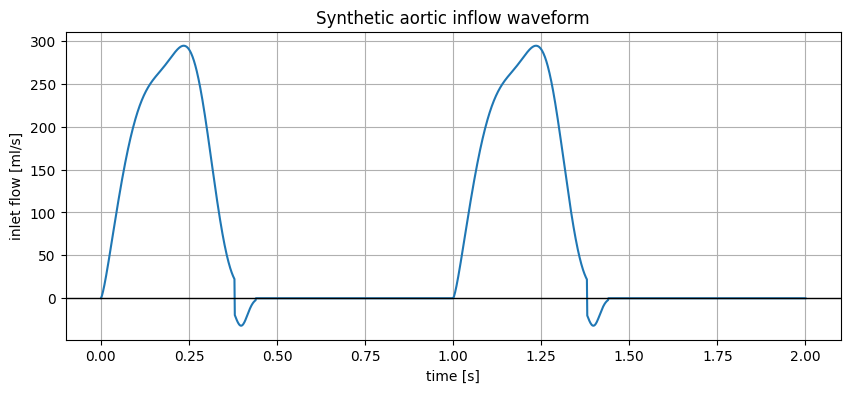

Q peak [ml/s]: 294.398723353155
Q min [ml/s]: -32.0334664240778
Stroke volume first cycle [ml]: 69.98942574610462


In [ ]:
T_CARDIAC = 1.0 # [s], 60 bpm
T_SYS = 0.38 # [s], systolic ejection duration

STROKE_VOLUME_ML = 70.0
STROKE_VOLUME = STROKE_VOLUME_ML * 1e-6  # [m^3]


def inlet_shape_raw(tau):
    """
    Compute a dimensionless synthetic aortic inflow shape.

    Creates a broad systolic ejection pulse with a small negative
    recoil component after systole.

    Args:
        tau: Time within one cardiac cycle.

    Returns:
        Dimensionless inlet flow shape value.
    """

    if tau < 0.0:
        return 0.0

    if tau < T_SYS:
        x = tau / T_SYS

        a = 1.4
        b = 2.2

        main = (x ** a) * ((1.0 - x) ** b)

        shoulder = 0.06 * np.exp(
            -0.5 * ((tau - 0.27) / 0.055) ** 2
        )

        return main + shoulder

    elif tau < T_SYS + 0.06:
        return -0.012 * np.exp(
            -0.5 * ((tau - (T_SYS + 0.018)) / 0.018) ** 2
        )

    else:
        return 0.0


# Calibrate to stroke volume
ts_cal = np.linspace(0, T_CARDIAC, 3000)
shape = np.array([inlet_shape_raw(t) for t in ts_cal])
area_shape = trapezoid(shape, ts_cal)

Q_SCALE = STROKE_VOLUME / area_shape


def inlet_flow(t):
    tau = t % T_CARDIAC
    return Q_SCALE * inlet_shape_raw(tau)


# Diagnostic plot
ts = np.linspace(0, 2.0, 2000)
qs = np.array([inlet_flow(t) for t in ts])

plt.figure(figsize=(10, 4))
plt.plot(ts, qs * 1e6)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("time [s]")
plt.ylabel("inlet flow [ml/s]")
plt.title("Synthetic aortic inflow waveform")
plt.grid(True)
plt.show()

print("Q peak [ml/s]:", qs.max() * 1e6)
print("Q min [ml/s]:", qs.min() * 1e6)
print("Stroke volume first cycle [ml]:", trapezoid(qs[ts < 1.0], ts[ts < 1.0]) * 1e6)

## Initial pressure state

The simulation starts from a uniform reference pressure:

```python
P_REF = 90 mmHg

In [5]:
P_REF = 90.0 * MMHG
P_VENOUS = 5.0 * MMHG


def initialize_state(A0v, betav, Nv, P_init):
    """
    Initialize each vessel at uniform pressure P_init and zero flow.
    """

    A = []
    Q = []

    for i in range(len(A0v)):
        A_init = pressure_to_area(P_init, A0v[i], betav[i])

        A.append(np.full(Nv[i], A_init, dtype=float))
        Q.append(np.zeros(Nv[i], dtype=float))

    return A, Q


A_ref_v = np.array([
    pressure_to_area(P_REF, A0v[i], betav[i])
    for i in range(len(A0v))
])

print("P_REF mmHg:", P_REF / MMHG)
print("A_ref/A0 range:", np.min(A_ref_v / A0v), np.max(A_ref_v / A0v))

P_REF mmHg: 90.0
A_ref/A0 range: 1.034322905557006 1.6238796652932406


## MacCormack solver step

The interior points of each vessel are updated using a MacCormack predictor-corrector scheme.

The solved variables are:

```text
A = cross-sectional area
Q = volumetric flow

In [ ]:
def compute_flux(A, Q, A0, beta, rho=RHO):
    """
    Compute conservative fluxes for the 1D blood-flow equations.

    Args:
        A: Vessel area array.
        Q: Flow array.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.
        rho: Blood density.

    Returns:
        (F1, F2) flux arrays for area and flow equations.
    """

    A_safe = np.maximum(A, 1e-12)

    P = area_to_pressure(A_safe, A0, beta)

    F1 = Q
    F2 = Q**2 / A_safe + P * A_safe / rho

    return F1, F2


def maccormack_step(A, Q, A0, beta, dx, dt):
    """
    Run one MacCormack predictor-corrector step for one vessel.

    Updates only interior numerical values; boundary conditions are
    expected to be applied outside this function.

    Args:
        A: Vessel area array.
        Q: Flow array.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.
        dx: Spatial step size.
        dt: Time step.

    Returns:
        Updated (A_new, Q_new) arrays.
    """

    N = len(A)

    if N < 3:
        return A, Q

    A_new = A.copy()
    Q_new = Q.copy()

    # Predictor
    F1, F2 = compute_flux(A, Q, A0, beta)

    A_pred = A.copy()
    Q_pred = Q.copy()

    A_pred[:-1] = A[:-1] - dt / dx * (F1[1:] - F1[:-1])
    Q_pred[:-1] = Q[:-1] - dt / dx * (F2[1:] - F2[:-1])

    A_pred = np.maximum(A_pred, 1e-12)

    # Corrector
    F1p, F2p = compute_flux(A_pred, Q_pred, A0, beta)

    A_new[1:] = 0.5 * (
        A[1:] + A_pred[1:] - dt / dx * (F1p[1:] - F1p[:-1])
    )

    Q_new[1:] = 0.5 * (
        Q[1:] + Q_pred[1:] - dt / dx * (F2p[1:] - F2p[:-1])
    )

    A_new = np.maximum(A_new, 1e-12)

    return A_new, Q_new


def step_all_vessels_uncoupled(A, Q, A0v, betav, dxv, dt):
    """
    Apply one uncoupled MacCormack step to all vessels.

    Each vessel is stepped independently, while inlet, outlet,
    and junction coupling are handled elsewhere.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        dxv: Spatial step size per vessel.
        dt: Time step.

    Returns:
        Updated (A_new, Q_new) vessel lists.
    """

    A_new = []
    Q_new = []

    for i in range(len(A)):
        Ai, Qi = maccormack_step(
            A[i],
            Q[i],
            A0v[i],
            betav[i],
            dxv[i],
            dt
        )

        A_new.append(Ai)
        Q_new.append(Qi)

    return A_new, Q_new

## Baseline vessel connection coupling

After each vessel interior is updated, connected vessels must exchange pressure and flow information.

This baseline solver uses a simplified wave-aware coupling method.

It is not a full nonlinear Riemann solver at bifurcations.  
Instead, it estimates an interface pressure using characteristic impedance and then updates inlet/outlet flow using a linear wave relation:

```text
dQ = dP / Z0

In [ ]:
def apply_connections_simple(A, Q, children_map_idx, A0v, betav, Z0v):
    """
    Apply simple wave-aware coupling between connected vessels.

    Updates parent outlet and child inlet boundary values using a shared
    interface pressure and a linear characteristic relation between
    pressure change and flow change.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        children_map_idx: Mapping from parent vessel index to child indices.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.

    Returns:
        Updated (A, Q) vessel lists.
    """

    for parent, children in children_map_idx.items():

        Pp = area_to_pressure(
            A[parent][-1],
            A0v[parent],
            betav[parent]
        )

        Qp = Q[parent][-1]

        # ========================================================
        # Linear connection
        # ========================================================
        if len(children) == 1:

            child = children[0]

            Pc = area_to_pressure(
                A[child][0],
                A0v[child],
                betav[child]
            )

            Qc = Q[child][0]

            gp = 1.0 / Z0v[parent]
            gc = 1.0 / Z0v[child]

            # shared pressure at interface
            P_int = (gp * Pp + gc * Pc) / (gp + gc)

            # wave update:
            # child inlet flow changes according to pressure jump
            Q_child_new = Qc + (P_int - Pc) / Z0v[child]

            # parent outlet gets same flow for conservation at this simple interface
            Q_parent_new = Q_child_new

            A[parent][-1] = pressure_to_area(
                P_int,
                A0v[parent],
                betav[parent]
            )

            A[child][0] = pressure_to_area(
                P_int,
                A0v[child],
                betav[child]
            )

            Q[parent][-1] = Q_parent_new
            Q[child][0] = Q_child_new

        # ========================================================
        # Bifurcation
        # ========================================================
        elif len(children) == 2:

            c1, c2 = children

            P1 = area_to_pressure(
                A[c1][0],
                A0v[c1],
                betav[c1]
            )

            P2 = area_to_pressure(
                A[c2][0],
                A0v[c2],
                betav[c2]
            )

            Q1_old = Q[c1][0]
            Q2_old = Q[c2][0]

            gp = 1.0 / Z0v[parent]
            g1 = 1.0 / Z0v[c1]
            g2 = 1.0 / Z0v[c2]

            # shared junction pressure
            P_int = (gp * Pp + g1 * P1 + g2 * P2) / (gp + g1 + g2)

            # wave-consistent child inlet updates
            Q1 = Q1_old + (P_int - P1) / Z0v[c1]
            Q2 = Q2_old + (P_int - P2) / Z0v[c2]

            A[parent][-1] = pressure_to_area(
                P_int,
                A0v[parent],
                betav[parent]
            )

            A[c1][0] = pressure_to_area(
                P_int,
                A0v[c1],
                betav[c1]
            )

            A[c2][0] = pressure_to_area(
                P_int,
                A0v[c2],
                betav[c2]
            )

            # parent flow equals total outflow into children
            Q[parent][-1] = Q1 + Q2
            Q[c1][0] = Q1
            Q[c2][0] = Q2

    return A, Q

## 3-element Windkessel terminal setup

Terminal arteries are connected to simplified downstream vascular beds.

Each terminal vessel receives a 3-element Windkessel model:

```text
R1 — proximal resistance
C  — compliance
R2 — distal resistance

In [8]:
P_VENOUS = 5.0 * MMHG  # 5 mmHg

# Approx global peripheral resistance:
# pressure drop / cardiac output
# 70 ml/s = 4.2 L/min
TOTAL_R = (100.0 * MMHG - P_VENOUS) / (70e-6)

terminal_A0 = A0v[terminal_idx]
weights = terminal_A0 / terminal_A0.sum()

R_total_i = TOTAL_R / weights

wk_R1 = np.zeros(len(A0v))
wk_R2 = np.zeros(len(A0v))
wk_C = np.zeros(len(A0v))
wk_Pc = np.zeros(len(A0v))

terminal_pos = {
    int(idx): k
    for k, idx in enumerate(terminal_idx)
}

for i in terminal_idx:
    k = terminal_pos[int(i)]

    R_total = R_total_i[k]

    wk_R1[i] = 0.10 * R_total
    wk_R2[i] = 0.90 * R_total

    # crude compliance allocation
    wk_C[i] = 1.5e-9 * weights[k]

    wk_Pc[i] = P_REF

print("Terminals:", len(terminal_idx))
print("TOTAL_R:", TOTAL_R)
print("R1 range:", wk_R1[wk_R1 > 0].min(), wk_R1.max())
print("R2 range:", wk_R2[wk_R2 > 0].min(), wk_R2.max())
print("C range:", wk_C[wk_C > 0].min(), wk_C.max())

Terminals: 43
TOTAL_R: 180937000.00000003
R1 range: 293747734.9833211 7480205480.287597
R2 range: 2643729614.8498893 67321849322.58836
C range: 3.628316103283905e-12 9.239407412466019e-11


## Windkessel terminal boundary condition

At each terminal vessel, the solver applies a 3-element Windkessel boundary condition.

The terminal boundary condition does three things:

1. estimates outgoing wave information from the last interior point  
2. computes terminal outflow using characteristic impedance and proximal resistance  
3. updates the Windkessel capacitor pressure over time  

The capacitor pressure evolves according to:

```text
C · dPc/dt = Qout - (Pc - Pv) / R2

In [ ]:
def apply_windkessel_terminals(A, Q, terminal_idx, A0v, betav, Z0v,
                               wk_R1, wk_R2, wk_C, wk_Pc,
                               dt, P_venous=P_VENOUS):
    """
    Apply 3-element Windkessel boundary conditions at terminal vessels.

    Uses characteristic coupling from the last interior point to compute
    terminal flow, updates Windkessel capacitor pressure, then imposes
    terminal pressure and flow at each outlet.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        terminal_idx: Indices of terminal vessels.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.
        wk_R1: Proximal Windkessel resistance array.
        wk_R2: Distal Windkessel resistance array.
        wk_C: Windkessel compliance array.
        wk_Pc: Windkessel capacitor pressure array.
        dt: Time step.
        P_venous: Venous pressure.

    Returns:
        Updated (A, Q, wk_Pc).
    """

    for i in terminal_idx:

        P_inside = area_to_pressure(
            A[i][-2],
            A0v[i],
            betav[i]
        )

        Q_inside = Q[i][-2]
        Z = Z0v[i]

        W_plus = Q_inside + P_inside / Z

        Q_out = (Z * W_plus - wk_Pc[i]) / (Z + wk_R1[i])

        # Safety: allow some reverse flow, avoid numerical insanity
        Q_out = np.clip(Q_out, -5e-5, 5e-4)

        dPc_dt = (
            Q_out - (wk_Pc[i] - P_venous) / wk_R2[i]
        ) / wk_C[i]

        wk_Pc[i] += dt * dPc_dt

        wk_Pc[i] = np.clip(
            wk_Pc[i],
            P_venous,
            180.0 * MMHG
        )

        P_terminal = wk_Pc[i] + wk_R1[i] * Q_out

        P_terminal = np.clip(
            P_terminal,
            40.0 * MMHG,
            180.0 * MMHG
        )

        A[i][-1] = pressure_to_area(
            P_terminal,
            A0v[i],
            betav[i]
        )

        Q[i][-1] = Q_out

    return A, Q, wk_Pc

## Numerical stabilization

This baseline solver uses simple numerical limiters to prevent unstable or non-physical states.

The stabilizer limits:

- vessel area relative to the reference pressure area
- flow velocity `u = Q / A`

This is not a physiological model component.  
It is a numerical safety mechanism used to keep the first CPU baseline stable.

The final active stabilizer clips area to:

```text
0.85 · A_ref ≤ A ≤ 1.35 · A_ref

In [ ]:
def limit_flow_velocity(A, Q, vmax=2.0):
    """
    Limit flow velocity by clipping u = Q / A.

    Args:
        A: Vessel area array.
        Q: Flow array.
        vmax: Maximum allowed velocity magnitude.

    Returns:
        Flow array after velocity limiting.
    """
    A_safe = np.maximum(A, 1e-12)
    u = Q / A_safe
    u_limited = np.clip(u, -vmax, vmax)
    return u_limited * A_safe


def stabilize_all(A, Q, A_ref_v, vmax=2.0):
    """
    Stabilize all vessel states by clamping area and velocity.

    Limits vessel area to a safe range around the reference area,
    then limits flow using the maximum allowed velocity.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        A_ref_v: Reference area per vessel.
        vmax: Maximum allowed velocity magnitude.

    Returns:
        Stabilized (A, Q) vessel lists.
    """
    for i in range(len(A)):
        A[i] = np.clip(
            A[i],
            0.85 * A_ref_v[i],
            1.35 * A_ref_v[i]
        )

        Q[i] = limit_flow_velocity(
            A[i],
            Q[i],
            vmax=vmax
        )

    return A, Q

## Root inlet boundary condition

The aortic root receives the prescribed cardiac inflow waveform.

Instead of simply forcing both pressure and flow, this boundary condition prescribes inlet flow and estimates inlet pressure using a Riemann-like compatibility relation with the first interior point.

This is important because directly imposing both pressure and flow would over-constrain the hyperbolic 1D system.

The boundary condition therefore:

1. evaluates the target inflow `Q_in(t)`
2. reads pressure and flow from the first interior grid point
3. estimates inlet pressure using characteristic impedance
4. converts that pressure back into inlet area
5. sets the inlet flow to the prescribed waveform

This gives a more stable and physically consistent root boundary than simply assigning `Q[0] = Q_in`.

In [ ]:
def apply_root_inlet_riemann(A, Q, root_idx, t, A0v, betav, Z0v):
    """
    Apply a Riemann-like inlet boundary condition at the root vessel.

    Prescribes inlet flow from inlet_flow(t), then computes compatible
    inlet pressure and area from the first interior point.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        root_idx: Index of the root vessel.
        t: Current simulation time.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.

    Returns:
        Updated (A, Q) vessel lists.
    """

    Q_in = inlet_flow(t)

    A_inside = A[root_idx][1]
    Q_inside = Q[root_idx][1]

    P_inside = area_to_pressure(
        A_inside,
        A0v[root_idx],
        betav[root_idx]
    )

    Z = Z0v[root_idx]

    P_in = P_inside + Z * (Q_in - Q_inside)

    P_in = np.clip(
        P_in,
        40.0 * MMHG,
        200.0 * MMHG
    )

    A[root_idx][0] = pressure_to_area(
        P_in,
        A0v[root_idx],
        betav[root_idx]
    )

    Q[root_idx][0] = Q_in

    return A, Q

## Main simulation loop

This loop uses the same baseline CPU solver structure as before:

1. root inlet boundary condition,
2. network connection coupling,
3. terminal Windkessel boundary condition,
4. stabilization,
5. uncoupled MacCormack step,
6. boundary conditions again,
7. signal/snapshot recording.

The BG wall model mainly changes `betav`, `c0v`, and `Z0v`, so the wave travels faster in smaller vessels and the time step is smaller.

For a first smoke test, set:

```python
T_TEST = 0.20
```

For a full two-cycle baseline, set:

```python
T_TEST = 2.0
```


In [12]:
# Reference pressures
P_REF = 90.0 * MMHG
P_VENOUS = 5.0 * MMHG

# Root index from parsed data
ROOT_IDX = int(root_idx[0]) if np.ndim(root_idx) > 0 else int(root_idx)
print("ROOT_IDX:", ROOT_IDX, order[ROOT_IDX])
print("P_REF mmHg:", P_REF / MMHG)


# Use dt_global already computed in the CFL cell above.
# Do not use the parser's raw dt_global directly for this CPU baseline.
print("CFL_SOLVER:", CFL_SOLVER)
print("dt_global:", dt_global)
print("n_steps for 2s:", int(2.0 / dt_global))

cfl_actual = c0v * dt_global / dxv
print("max CFL actual:", cfl_actual.max())
print("min CFL actual:", cfl_actual.min())


# Reference area for stabilizer
A_ref_v = np.array([
    pressure_to_area(P_REF, A0v[i], betav[i])
    for i in range(len(A0v))
])

print("A_ref/A0 range:", np.min(A_ref_v / A0v), np.max(A_ref_v / A0v))


# Initialize state
A, Q = initialize_state(A0v, betav, Nv, P_REF)

# Windkessel capacitor pressure reset
wk_Pc[:] = P_REF


# Simulation duration
T_TEST = 2.0
n_steps = int(T_TEST / dt_global)

print("n_steps:", n_steps)


# HISTORIES
p_root_hist = []
q_root_hist = []

p_brachial_hist = []
p_brachial_in_hist = []
p_brachial_mid_hist = []
p_brachial_out_hist = []

q_brachial_in_hist = []
q_brachial_mid_hist = []
q_brachial_out_hist = []

t_hist = []

# Snapshots for animation
snapshot_dt = 0.01
next_snapshot_t = 0.0
snapshots = {}

# Vessel of interest
brachial_idx = vessel_to_idx["brachial_R34"]

watch_vessel_names = [
    "ascending_aorta_C0",
    "brachial_R34",
    "femoral_R222",
    "posterior_tibial_T4_R236",
    "internal_carotid_R8",
]

watch_vessel_idx = {
    name: vessel_to_idx[name]
    for name in watch_vessel_names
}

watch_pressure_hist = {name: [] for name in watch_vessel_names}
watch_flow_hist = {name: [] for name in watch_vessel_names}

# Progress timing
t_start = time.time()


# MAIN LOOP
for step in range(n_steps):

    t = step * dt_global
    # Progress / stability diagnostics
    if step % 1000 == 0 and step > 0:

        elapsed_now = time.time() - t_start
        progress = step / n_steps
        eta = elapsed_now * (1.0 - progress) / progress

        max_u = max(
            np.max(np.abs(Q[i] / np.maximum(A[i], 1e-12)))
            for i in range(len(A))
        )

        min_area_ratio = min(
            np.min(A[i] / A0v[i])
            for i in range(len(A))
        )

        max_area_ratio = max(
            np.max(A[i] / A0v[i])
            for i in range(len(A))
        )

        print(
            f"[{progress*100:5.1f}%] "
            f"step={step}/{n_steps} | "
            f"t={t:.3f}s | "
            f"elapsed={elapsed_now:.1f}s | "
            f"ETA={eta:.1f}s | "
            f"max|u|={max_u:.2f} m/s | "
            f"min(A/A0)={min_area_ratio:.3f} | "
            f"max(A/A0)={max_area_ratio:.3f}",
            flush=True
        )

    #  ROOT INLET — RIEMANN-LIKE BC
    A, Q = apply_root_inlet_riemann(
        A, Q,
        root_idx=ROOT_IDX,
        t=t,
        A0v=A0v,
        betav=betav,
        Z0v=Z0v
    )

    # NETWORK CONNECTIONS — WAVE-AWARE SIMPLE COUPLING
    A, Q = apply_connections_simple(
        A, Q,
        children_map_idx,
        A0v,
        betav,
        Z0v
    )

    # 3WINDKESSEL TERMINALS
    A, Q, wk_Pc = apply_windkessel_terminals(
        A, Q,
        terminal_idx,
        A0v,
        betav,
        Z0v,
        wk_R1,
        wk_R2,
        wk_C,
        wk_Pc,
        dt_global
    )

    # STABILIZE BEFORE SOLVER STEP
    A, Q = stabilize_all(
        A, Q,
        A_ref_v,
        vmax=2.0
    )

    #  SOLVER STEP
    A, Q = step_all_vessels_uncoupled(
        A, Q,
        A0v,
        betav,
        dxv,
        dt_global
    )
  
    #  STABILIZE AFTER SOLVER STEP
    A, Q = stabilize_all(
        A, Q,
        A_ref_v,
        vmax=2.0
    )

    # NUMERICAL FAILURE CHECK
    bad = False

    for vi in range(len(A)):

        if np.isnan(A[vi]).any() or np.isnan(Q[vi]).any():
            print("NaN in vessel:", vi, order[vi], "at step", step, "t", t)
            bad = True
            break

        if np.isinf(A[vi]).any() or np.isinf(Q[vi]).any():
            print("Inf in vessel:", vi, order[vi], "at step", step, "t", t)
            bad = True
            break

        if np.min(A[vi]) <= 0:
            print("Non-positive A in vessel:", vi, order[vi])
            print("min A:", np.min(A[vi]))
            bad = True
            break

    if bad:
        break


    # REAPPLY BCs AFTER STEP
    A, Q = apply_root_inlet_riemann(
        A, Q,
        root_idx=ROOT_IDX,
        t=t,
        A0v=A0v,
        betav=betav,
        Z0v=Z0v
    )

    A, Q = apply_connections_simple(
        A, Q,
        children_map_idx,
        A0v,
        betav,
        Z0v
    )

    A, Q, wk_Pc = apply_windkessel_terminals(
        A, Q,
        terminal_idx,
        A0v,
        betav,
        Z0v,
        wk_R1,
        wk_R2,
        wk_C,
        wk_Pc,
        dt_global
    )

    A, Q = stabilize_all(
        A, Q,
        A_ref_v,
        vmax=2.0
    )


    # RECORD ROOT OUTLET
    p_root = area_to_pressure(
        A[ROOT_IDX],
        A0v[ROOT_IDX],
        betav[ROOT_IDX]
    ) / MMHG

    p_root_hist.append(p_root[-1])
    q_root_hist.append(Q[ROOT_IDX][-1] * 1e6)

    
    #  RECORD BRACHIAL PRESSURE AND FLOW
    brachial_A = A[brachial_idx]
    brachial_Q = Q[brachial_idx]

    mid = len(brachial_A) // 2

    p_brachial_in = area_to_pressure(
        brachial_A[0],
        A0v[brachial_idx],
        betav[brachial_idx]
    ) / MMHG

    p_brachial_mid = area_to_pressure(
        brachial_A[mid],
        A0v[brachial_idx],
        betav[brachial_idx]
    ) / MMHG

    p_brachial_out = area_to_pressure(
        brachial_A[-1],
        A0v[brachial_idx],
        betav[brachial_idx]
    ) / MMHG

    p_brachial_hist.append(p_brachial_mid)

    p_brachial_in_hist.append(p_brachial_in)
    p_brachial_mid_hist.append(p_brachial_mid)
    p_brachial_out_hist.append(p_brachial_out)

    q_brachial_in_hist.append(brachial_Q[0] * 1e6)
    q_brachial_mid_hist.append(brachial_Q[mid] * 1e6)
    q_brachial_out_hist.append(brachial_Q[-1] * 1e6)

    t_hist.append(t)


    #  WATCHLIST RECORDING
    for name, idx in watch_vessel_idx.items():

        mid_idx = len(A[idx]) // 2

        P_mid = area_to_pressure(
            A[idx][mid_idx],
            A0v[idx],
            betav[idx]
        ) / MMHG

        Q_mid = Q[idx][mid_idx] * 1e6

        watch_pressure_hist[name].append(P_mid)
        watch_flow_hist[name].append(Q_mid)

    #  SAVE PRESSURE SNAPSHOTS FOR ANIMATION
    if t >= next_snapshot_t:

        vessel_pressures = []

        for i in range(len(A)):

            P_i = area_to_pressure(
                A[i],
                A0v[i],
                betav[i]
            ) / MMHG

            # For visualization, use vessel-averaged pressure.
            # This is more robust for very short vessels.
            if len(P_i) > 2:
                p_vis = np.mean(P_i[1:-1])
            else:
                p_vis = np.mean(P_i)

            vessel_pressures.append(p_vis)

        snapshots[round(next_snapshot_t, 4)] = np.array(vessel_pressures)
        next_snapshot_t += snapshot_dt



# SUMMARY
print("done")
print("Steps completed:", step + 1, "/", n_steps)
print("Any NaN A:", any(np.isnan(x).any() for x in A))
print("Any NaN Q:", any(np.isnan(x).any() for x in Q))

print("Min A/A0:", min((A[i] / A0v[i]).min() for i in range(len(A))))
print("Max A/A0:", max((A[i] / A0v[i]).max() for i in range(len(A))))

if len(p_root_hist) > 0:
    print("Root outlet pressure range mmHg:", min(p_root_hist), max(p_root_hist))
    print("Root outlet flow range ml/s:", min(q_root_hist), max(q_root_hist))
    print("Brachial pressure range mmHg:", min(p_brachial_hist), max(p_brachial_hist))

if np.any(wk_Pc > 0):
    print(
        "wk_Pc min/max mmHg:",
        wk_Pc[wk_Pc > 0].min() / MMHG,
        wk_Pc.max() / MMHG
    )

    print(
        "wk_Pc near low clamp:",
        np.sum(wk_Pc[terminal_idx] <= 5.01 * MMHG)
    )

    print(
        "wk_Pc near high clamp:",
        np.sum(wk_Pc[terminal_idx] >= 179.99 * MMHG)
    )

print(
    "Snapshots saved:",
    sorted(snapshots.keys())[:10],
    "...",
    sorted(snapshots.keys())[-10:] if len(snapshots) > 10 else sorted(snapshots.keys())
)

# CONVERT HISTORIES TO ARRAYS
t_arr = np.array(t_hist)

p_root_arr = np.array(p_root_hist)
q_root_arr = np.array(q_root_hist)

p_brachial_arr = np.array(p_brachial_hist)

p_brachial_in_arr = np.array(p_brachial_in_hist)
p_brachial_mid_arr = np.array(p_brachial_mid_hist)
p_brachial_out_arr = np.array(p_brachial_out_hist)

q_brachial_in_arr = np.array(q_brachial_in_hist)
q_brachial_mid_arr = np.array(q_brachial_mid_hist)
q_brachial_out_arr = np.array(q_brachial_out_hist)

watch_pressure_arr = {
    name: np.array(vals)
    for name, vals in watch_pressure_hist.items()
}

watch_flow_arr = {
    name: np.array(vals)
    for name, vals in watch_flow_hist.items()
}


# SAVE RESULTS OBJECT
baseline_results = {
    "mode": "baseline_cpu_bg_wall_model",
    "T_TEST": T_TEST,
    "dt": dt_global,
    "CFL_SOLVER": CFL_SOLVER,
    "parsed_file": str(PARSED_FILE),
    "wall_model": adan.get("wall_model", "unknown"),

    "t": t_arr.copy(),

    "p_root": p_root_arr.copy(),
    "q_root": q_root_arr.copy(),

    "p_brachial": p_brachial_arr.copy(),

    "p_brachial_in": p_brachial_in_arr.copy(),
    "p_brachial_mid": p_brachial_mid_arr.copy(),
    "p_brachial_out": p_brachial_out_arr.copy(),

    "q_brachial_in": q_brachial_in_arr.copy(),
    "q_brachial_mid": q_brachial_mid_arr.copy(),
    "q_brachial_out": q_brachial_out_arr.copy(),

    "snapshots": snapshots.copy(),

    "A_final": [a.copy() for a in A],
    "Q_final": [q.copy() for q in Q],
    "wk_Pc_final": wk_Pc.copy(),

    "watch_pressure": {
        name: arr.copy()
        for name, arr in watch_pressure_arr.items()
    },

    "watch_flow": {
        name: arr.copy()
        for name, arr in watch_flow_arr.items()
    },

    "watch_vessel_names": watch_vessel_names.copy(),
    "parser_diagnostics": adan.get("diagnostics", {}),
}

print("Saved baseline_results object")
print("baseline keys:", baseline_results.keys())

ROOT_IDX: 0 ascending_aorta_C0
P_REF mmHg: 90.0
CFL_SOLVER: 0.1
dt_global: 1.867935843904349e-05
n_steps for 2s: 107070
max CFL actual: 0.1
min CFL actual: 0.01747913246150141
A_ref/A0 range: 1.034322905557006 1.6238796652932406
n_steps: 107070
[  0.9%] step=1000/107070 | t=0.019s | elapsed=12.6s | ETA=1341.6s | max|u|=0.18 m/s | min(A/A0)=1.032 | max(A/A0)=1.625
[  1.9%] step=2000/107070 | t=0.037s | elapsed=24.7s | ETA=1299.5s | max|u|=0.40 m/s | min(A/A0)=1.028 | max(A/A0)=1.639
[  2.8%] step=3000/107070 | t=0.056s | elapsed=37.4s | ETA=1298.5s | max|u|=0.57 m/s | min(A/A0)=1.025 | max(A/A0)=1.661
[  3.7%] step=4000/107070 | t=0.075s | elapsed=49.4s | ETA=1273.0s | max|u|=0.67 m/s | min(A/A0)=1.024 | max(A/A0)=1.685
[  4.7%] step=5000/107070 | t=0.093s | elapsed=61.4s | ETA=1252.7s | max|u|=0.74 m/s | min(A/A0)=1.024 | max(A/A0)=1.720
[  5.6%] step=6000/107070 | t=0.112s | elapsed=73.3s | ETA=1235.5s | max|u|=0.74 m/s | min(A/A0)=1.026 | max(A/A0)=1.760
[  6.5%] step=7000/107070 | t

## Save BG-wall baseline solver results

After the simulation finishes, the recorded histories are converted into NumPy arrays and saved into a results dictionary.

The saved object contains:

- simulation metadata
- parser file name and wall-model metadata
- root pressure and flow
- right brachial pressure and flow
- brachial inlet, middle, and outlet signals
- selected watchlist vessel signals
- pressure snapshots for animation
- final area and flow fields
- final Windkessel capacitor pressures
- validation summary

Main output file:

```python
baseline_p90_cpu_bg_results.pkl
```

Versioned archival output:

```python
results/baseline_p90_cpu_bg_cfl01_v1.pkl
```


In [13]:
t_arr = np.array(t_hist)

p_root_arr = np.array(p_root_hist)
q_root_arr = np.array(q_root_hist)

p_brachial_arr = np.array(p_brachial_hist)

p_brachial_in_arr = np.array(p_brachial_in_hist)
p_brachial_mid_arr = np.array(p_brachial_mid_hist)
p_brachial_out_arr = np.array(p_brachial_out_hist)

q_brachial_in_arr = np.array(q_brachial_in_hist)
q_brachial_mid_arr = np.array(q_brachial_mid_hist)
q_brachial_out_arr = np.array(q_brachial_out_hist)

watch_pressure_arr = {
    name: np.array(vals)
    for name, vals in watch_pressure_hist.items()
}

watch_flow_arr = {
    name: np.array(vals)
    for name, vals in watch_flow_hist.items()
}


# Build results object
baseline_p90_cpu_results = {
    # Metadata
    "mode": "baseline_cpu_bg_wall_model",
    "description": (
        "Stable CPU baseline for ADAN-86 1D pressure propagation using the fixed BG wall model parser. "
        "Uses Riemann-like root inlet, wave-aware simple connections, "
        "and characteristic-coupled 3-element Windkessel terminals."
    ),

    "parsed_file": str(PARSED_FILE),
    "wall_model": adan.get("wall_model", "unknown"),
    "parser_diagnostics": adan.get("diagnostics", {}),

    "T_TEST": T_TEST,
    "dt": dt_global,
    "CFL_SOLVER": CFL_SOLVER,

    "P_REF_mmHg": P_REF / MMHG,
    "P_VENOUS_mmHg": P_VENOUS / MMHG,

    "root_idx": ROOT_IDX,
    "root_vessel": order[ROOT_IDX],

    "n_vessels": len(order),
    "n_terminals": len(terminal_idx),
    "watch_vessel_names": watch_vessel_names.copy(),

    # Main time arrays
    "t": t_arr.copy(),

    # Root signals
    "p_root": p_root_arr.copy(),
    "q_root": q_root_arr.copy(),

    # Brachial signals
    "p_brachial": p_brachial_arr.copy(),
    "p_brachial_in": p_brachial_in_arr.copy(),
    "p_brachial_mid": p_brachial_mid_arr.copy(),
    "p_brachial_out": p_brachial_out_arr.copy(),
    "q_brachial_in": q_brachial_in_arr.copy(),
    "q_brachial_mid": q_brachial_mid_arr.copy(),
    "q_brachial_out": q_brachial_out_arr.copy(),


    # Animation snapshots
    "snapshots": {
        k: v.copy()
        for k, v in snapshots.items()
    },

    # Final solver state
    "A_final": [a.copy() for a in A],
    "Q_final": [q.copy() for q in Q],
    "wk_Pc_final": wk_Pc.copy(),

    # Watchlist signals
    "watch_pressure": {
        name: arr.copy()
        for name, arr in watch_pressure_arr.items()
    },

    "watch_flow": {
        name: arr.copy()
        for name, arr in watch_flow_arr.items()
    },
}


# Add quick validation summary into results
baseline_p90_cpu_results["validation"] = {
    "any_nan_A": any(np.isnan(x).any() for x in A),
    "any_nan_Q": any(np.isnan(x).any() for x in Q),

    "min_A_over_A0": float(
        min((A[i] / A0v[i]).min() for i in range(len(A)))
    ),
    "max_A_over_A0": float(
        max((A[i] / A0v[i]).max() for i in range(len(A)))
    ),

    "root_pressure_min_mmHg": float(p_root_arr.min()),
    "root_pressure_max_mmHg": float(p_root_arr.max()),

    "root_flow_min_ml_s": float(q_root_arr.min()),
    "root_flow_max_ml_s": float(q_root_arr.max()),

    "brachial_pressure_min_mmHg": float(p_brachial_arr.min()),
    "brachial_pressure_max_mmHg": float(p_brachial_arr.max()),

    "wk_Pc_min_mmHg": float(wk_Pc[wk_Pc > 0].min() / MMHG),
    "wk_Pc_max_mmHg": float(wk_Pc.max() / MMHG),

    "wk_Pc_near_low_clamp": int(
        np.sum(wk_Pc[terminal_idx] <= 5.01 * MMHG)
    ),
    "wk_Pc_near_high_clamp": int(
        np.sum(wk_Pc[terminal_idx] >= 179.99 * MMHG)
    ),
}


# Save under convenient name
main_path = Path("baseline_p90_cpu_bg_results.pkl")

with open(main_path, "wb") as f:
    pickle.dump(baseline_p90_cpu_results, f)

print("Saved:", main_path.resolve())


# Save versioned archival copy
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

versioned_path = RESULTS_DIR / "baseline_p90_cpu_bg_cfl01_v1.pkl"
with open(versioned_path, "wb") as f:
    pickle.dump(baseline_p90_cpu_results, f)

print("Saved:", versioned_path.resolve())



# Final report
print("\nKeys:")
print(baseline_p90_cpu_results.keys())

print("\nValidation:")
for k, v in baseline_p90_cpu_results["validation"].items():
    print(f"{k}: {v}")

print("\nFile sizes:")
print("main MB:", main_path.stat().st_size / 1024 / 1024)
print("versioned MB:", versioned_path.stat().st_size / 1024 / 1024)

Saved: D:\code\adan_project\NBS 2\baseline_p90_cpu_bg_results.pkl
Saved: D:\code\adan_project\NBS 2\results\baseline_p90_cpu_bg_cfl01_v1.pkl

Keys:
dict_keys(['mode', 'description', 'parsed_file', 'wall_model', 'parser_diagnostics', 'T_TEST', 'dt', 'CFL_SOLVER', 'P_REF_mmHg', 'P_VENOUS_mmHg', 'root_idx', 'root_vessel', 'n_vessels', 'n_terminals', 'watch_vessel_names', 't', 'p_root', 'q_root', 'p_brachial', 'p_brachial_in', 'p_brachial_mid', 'p_brachial_out', 'q_brachial_in', 'q_brachial_mid', 'q_brachial_out', 'snapshots', 'A_final', 'Q_final', 'wk_Pc_final', 'watch_pressure', 'watch_flow', 'validation'])

Validation:
any_nan_A: False
any_nan_Q: False
min_A_over_A0: 1.0218898572781758
max_A_over_A0: 1.6238796691372535
root_pressure_min_mmHg: 88.16598103396794
root_pressure_max_mmHg: 112.42341963281878
root_flow_min_ml_s: -23.866602127160423
root_flow_max_ml_s: 291.8022357550295
brachial_pressure_min_mmHg: 88.17804714542386
brachial_pressure_max_mmHg: 140.8939009201865
wk_Pc_min_mmHg: 6

## Baseline diagnostics

This section checks whether the simulation stayed numerically stable and whether the generated waveforms are in a reasonable range.

The diagnostics include:

- minimum and maximum area ratio
- root pressure range
- root flow range
- brachial pressure range
- Windkessel capacitor pressure range
- first-cycle waveform ranges
- second-cycle waveform ranges
- brachial inlet, middle, and outlet pressure/flow comparison

The second cycle is especially important because the first cycle starts from an artificial uniform-pressure initial condition.

In [14]:
print("Min A/A0:", min((A[i] / A0v[i]).min() for i in range(len(A))))
print("Max A/A0:", max((A[i] / A0v[i]).max() for i in range(len(A))))

print("Root pressure range mmHg:", p_root_arr.min(), p_root_arr.max())
print("Root flow range ml/s:", q_root_arr.min(), q_root_arr.max())
print("Brachial pressure range mmHg:", p_brachial_arr.min(), p_brachial_arr.max())

print(
    "wk_Pc range mmHg:",
    wk_Pc[wk_Pc > 0].min() / MMHG,
    wk_Pc.max() / MMHG
)

mask_cycle_1 = (t_arr >= 0.0) & (t_arr < 1.0)
mask_cycle_2 = (t_arr >= 1.0) & (t_arr < 2.0)

print("\nFIRST CYCLE 0-1s")
print("Root pressure mmHg:", p_root_arr[mask_cycle_1].min(), p_root_arr[mask_cycle_1].max())
print("Root flow ml/s:", q_root_arr[mask_cycle_1].min(), q_root_arr[mask_cycle_1].max())
print("Brachial pressure mmHg:", p_brachial_arr[mask_cycle_1].min(), p_brachial_arr[mask_cycle_1].max())

print("\nSECOND CYCLE 1-2s")
print("Root pressure mmHg:", p_root_arr[mask_cycle_2].min(), p_root_arr[mask_cycle_2].max())
print("Root flow ml/s:", q_root_arr[mask_cycle_2].min(), q_root_arr[mask_cycle_2].max())
print("Brachial pressure mmHg:", p_brachial_arr[mask_cycle_2].min(), p_brachial_arr[mask_cycle_2].max())

print("\nBRACHIAL SECOND CYCLE - LOCATIONS")
print("P in:", p_brachial_in_arr[mask_cycle_2].min(), p_brachial_in_arr[mask_cycle_2].max())
print("P mid:", p_brachial_mid_arr[mask_cycle_2].min(), p_brachial_mid_arr[mask_cycle_2].max())
print("P out:", p_brachial_out_arr[mask_cycle_2].min(), p_brachial_out_arr[mask_cycle_2].max())
print("Q in:", q_brachial_in_arr[mask_cycle_2].min(), q_brachial_in_arr[mask_cycle_2].max())
print("Q mid:", q_brachial_mid_arr[mask_cycle_2].min(), q_brachial_mid_arr[mask_cycle_2].max())
print("Q out:", q_brachial_out_arr[mask_cycle_2].min(), q_brachial_out_arr[mask_cycle_2].max())

Min A/A0: 1.0218898572781758
Max A/A0: 1.6238796691372535
Root pressure range mmHg: 88.16598103396794 112.42341963281878
Root flow range ml/s: -23.866602127160423 291.8022357550295
Brachial pressure range mmHg: 88.17804714542386 140.8939009201865
wk_Pc range mmHg: 66.01709522195539 90.0

FIRST CYCLE 0-1s
Root pressure mmHg: 88.16598103396794 112.42341963281878
Root flow ml/s: -23.866602127160423 291.8022357550295
Brachial pressure mmHg: 88.17807343462871 140.8939009201865

SECOND CYCLE 1-2s
Root pressure mmHg: 88.16598562706626 112.42341962593561
Root flow ml/s: -23.866542356293767 291.8022356649754
Brachial pressure mmHg: 88.17804714542386 140.89390091942826

BRACHIAL SECOND CYCLE - LOCATIONS
P in: 87.6060002995138 132.7238132301021
P mid: 88.17804714542386 140.89390091942826
P out: 87.44074169435837 140.3417255690956
Q in: -0.47245115938718824 8.431460993264006
Q mid: -0.9024959101061182 6.416333252092863
Q out: -0.3374162807236065 6.637125204013491


## Baseline waveform plots

The final plots inspect the generated pressure and flow signals.

The most important plot is the right brachial pressure waveform during the second cardiac cycle.

Compare:

- brachial inlet pressure
- brachial middle pressure
- brachial outlet pressure
- brachial inlet/middle/outlet flow
- pressure waveforms from selected arteries

These plots help evaluate whether the baseline solver produces a plausible delay and pressure-wave shape before moving to animation.


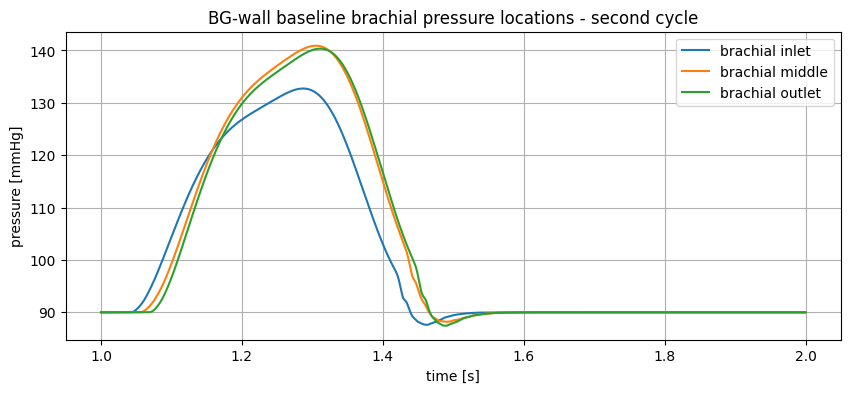

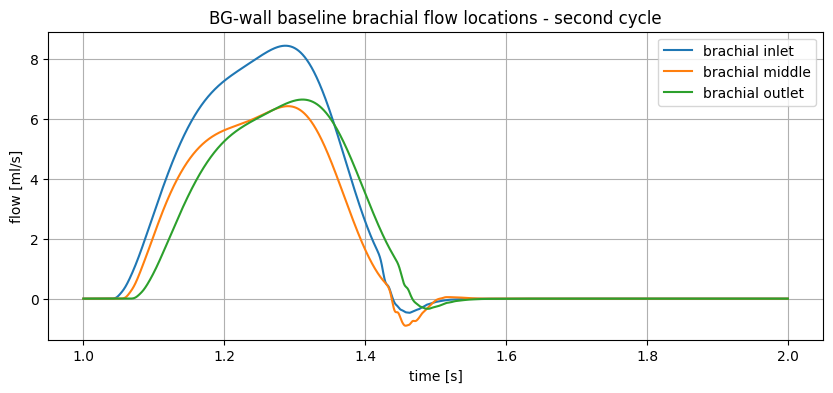

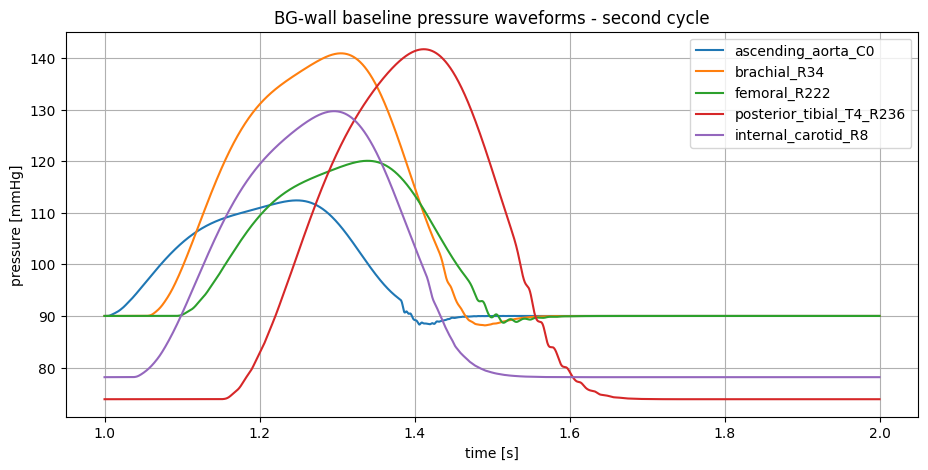

In [15]:
mask_cycle_2 = (t_arr >= 1.0) & (t_arr < 2.0)

plt.figure(figsize=(10, 4))
plt.plot(t_arr[mask_cycle_2], p_brachial_in_arr[mask_cycle_2], label="brachial inlet")
plt.plot(t_arr[mask_cycle_2], p_brachial_mid_arr[mask_cycle_2], label="brachial middle")
plt.plot(t_arr[mask_cycle_2], p_brachial_out_arr[mask_cycle_2], label="brachial outlet")
plt.xlabel("time [s]")
plt.ylabel("pressure [mmHg]")
plt.title("BG-wall baseline brachial pressure locations - second cycle")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_arr[mask_cycle_2], q_brachial_in_arr[mask_cycle_2], label="brachial inlet")
plt.plot(t_arr[mask_cycle_2], q_brachial_mid_arr[mask_cycle_2], label="brachial middle")
plt.plot(t_arr[mask_cycle_2], q_brachial_out_arr[mask_cycle_2], label="brachial outlet")
plt.xlabel("time [s]")
plt.ylabel("flow [ml/s]")
plt.title("BG-wall baseline brachial flow locations - second cycle")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(11, 5))
for name in watch_vessel_names:
    plt.plot(
        t_arr[mask_cycle_2],
        watch_pressure_arr[name][mask_cycle_2],
        label=name
    )

plt.xlabel("time [s]")
plt.ylabel("pressure [mmHg]")
plt.title("BG-wall baseline pressure waveforms - second cycle")
plt.legend()
plt.grid(True)
plt.show()